In [ ]:
import polars as pl
import matplotlib.pyplot as plt

# 1. Load and merge data

In [ ]:
df1=pl.read_parquet(
    'items.parquet',
    columns=['item_id','category_l1','category_l2','category_l3','category'])
df2=pl.read_parquet(
    'transactions-202411-to-202412.parquet',
    columns=['updated_date', 'item_id', 'quantity']
)
df=df1.join(df2, on='item_id', how='left')
df=df.drop_nulls()
print(len(df))
print(df.head())

6053447
shape: (5, 7)
┌────────────────┬─────────────┬───────────────┬─────────────┬──────────┬───────────────┬──────────┐
│ item_id        ┆ category_l1 ┆ category_l2   ┆ category_l3 ┆ category ┆ updated_date  ┆ quantity │
│ ---            ┆ ---         ┆ ---           ┆ ---         ┆ ---      ┆ ---           ┆ ---      │
│ str            ┆ str         ┆ str           ┆ str         ┆ str      ┆ datetime[μs]  ┆ i32      │
╞════════════════╪═════════════╪═══════════════╪═════════════╪══════════╪═══════════════╪══════════╡
│ 0007010000886  ┆ Babycare    ┆ Bình sữa, phụ ┆ Núm ty      ┆ Núm ty   ┆ 2024-12-30    ┆ 1        │
│                ┆             ┆ kiện          ┆             ┆ Pigeon   ┆ 10:22:00.050  ┆          │
│ 0007010000886  ┆ Babycare    ┆ Bình sữa, phụ ┆ Núm ty      ┆ Núm ty   ┆ 2024-12-28    ┆ 1        │
│                ┆             ┆ kiện          ┆             ┆ Pigeon   ┆ 13:39:11.750  ┆          │
│ 0007010000886  ┆ Babycare    ┆ Bình sữa, phụ ┆ Núm ty      ┆ Núm ty

# 2. Gom quantity theo week

In [ ]:
import polars as pl

df = df.with_columns([
    pl.col("updated_date").cast(pl.Datetime).dt.month().alias("month"),
    pl.col("updated_date").cast(pl.Datetime).dt.day().alias("day")
]).with_columns(
    pl.when((pl.col("month") == 11) & (pl.col("day") <= 7)).then(1)
      .when((pl.col("month") == 11) & (pl.col("day") <= 14)).then(2)
      .when((pl.col("month") == 11) & (pl.col("day") <= 21)).then(3)
      .when((pl.col("month") == 11) & (pl.col("day") >= 22)).then(4)
      .when((pl.col("month") == 12) & (pl.col("day") <= 7)).then(5)
      .when((pl.col("month") == 12) & (pl.col("day") <= 14)).then(6)
      .when((pl.col("month") == 12) & (pl.col("day") <= 21)).then(7)
      .when((pl.col("month") == 12) & (pl.col("day") >= 22)).then(8)
      .otherwise(None).alias("week_id")
)

df = df.drop_nulls(subset=["week_id"]).drop(["month", "day"])

group_cols = ['item_id', 'category_l1', 'category_l2', 'category_l3', 'category', 'week_id']

df_grouped = df.group_by(group_cols).agg(
    pl.col("quantity").sum().alias("quantity")
)

df_final = df_grouped.with_columns(
    pl.when(pl.col("week_id") == 4).then(pl.col("quantity") / 9)
      .when(pl.col("week_id") == 8).then(pl.col("quantity") / 10)
      .otherwise(pl.col("quantity") / 7).alias("normalized_quantity")
)

df_final = df_final.drop("quantity")

df_final = df_final.sort(["item_id", "week_id"])

print(df_final.head())
df_final.write_parquet('ket_qua_kinh_doanh.parquet')

shape: (5, 7)
┌──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬─────────┬──────────────┐
│ item_id      ┆ category_l1  ┆ category_l2 ┆ category_l3  ┆ category     ┆ week_id ┆ normalized_q │
│ ---          ┆ ---          ┆ ---         ┆ ---          ┆ ---          ┆ ---     ┆ uantity      │
│ str          ┆ str          ┆ str         ┆ str          ┆ str          ┆ i32     ┆ ---          │
│              ┆              ┆             ┆              ┆              ┆         ┆ f64          │
╞══════════════╪══════════════╪═════════════╪══════════════╪══════════════╪═════════╪══════════════╡
│ 000028000013 ┆ Đồ chơi &    ┆ 1Y+         ┆ Đồ chơi nước ┆ Đồ chơi nhà  ┆ 1       ┆ 74.142857    │
│ 8            ┆ Sách         ┆             ┆              ┆ tắm          ┆         ┆              │
│ 000028000013 ┆ Đồ chơi &    ┆ 1Y+         ┆ Đồ chơi nước ┆ Đồ chơi nhà  ┆ 2       ┆ 74.571429    │
│ 8            ┆ Sách         ┆             ┆              ┆ tắm          ┆  

# 3. Visualize

## 3.1 Group by theo toàn bộ

shape: (8, 2)
┌─────────┬────────────────┐
│ week_id ┆ total_quantity │
│ ---     ┆ ---            │
│ i32     ┆ f64            │
╞═════════╪════════════════╡
│ 1       ┆ 151337.571429  │
│ 2       ┆ 170517.142857  │
│ 3       ┆ 141132.571429  │
│ 4       ┆ 168366.111111  │
│ 5       ┆ 151011.0       │
│ 6       ┆ 154340.428571  │
│ 7       ┆ 147385.857143  │
│ 8       ┆ 133586.4       │
└─────────┴────────────────┘


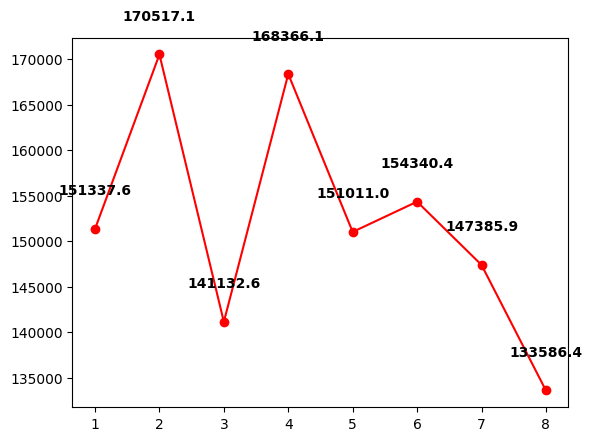

In [ ]:
df_combo = df_final.group_by('week_id').agg(
    pl.col("normalized_quantity").sum().alias("total_quantity")
)

df_combo=df_combo.sort('week_id')
print(df_combo)

plt.plot(df_combo['week_id'], df_combo['total_quantity'], 'r', marker='o')
for x, y in zip(df_combo['week_id'], df_combo['total_quantity']):
        plt.text(x, y + (max(df_combo['total_quantity']) * 0.02), f"{y:.1f}",
                ha='center', va='bottom', fontsize=10, color='black', fontweight='bold')

## 3.2 Group by theo cat 1

In [ ]:
df_cat1 = df_final.group_by(['category_l1', 'week_id']).agg(
    pl.col("normalized_quantity").sum().alias("total_quantity")
)

df_cat1=df_cat1.sort('week_id')
print(df_cat1.head())
print(len(df_cat1))

shape: (5, 3)
┌────────────────────┬─────────┬────────────────┐
│ category_l1        ┆ week_id ┆ total_quantity │
│ ---                ┆ ---     ┆ ---            │
│ str                ┆ i32     ┆ f64            │
╞════════════════════╪═════════╪════════════════╡
│ Hóa mỹ phẩm cho bé ┆ 1       ┆ 9093.571429    │
│ Tã                 ┆ 1       ┆ 11662.285714   │
│ Sữa                ┆ 1       ┆ 16786.857143   │
│ Đồ chơi & Sách     ┆ 1       ┆ 1782.714286    │
│ Thời trang         ┆ 1       ┆ 6288.285714    │
└────────────────────┴─────────┴────────────────┘
112


## 3.3 Group by theo cat 2

In [ ]:
df_cat2 = df_final.group_by(['category_l2', 'week_id']).agg(
    pl.col("normalized_quantity").sum().alias("total_quantity")
)

df_cat2=df_cat2.sort('week_id')
print(df_cat2.head())
print(len(df_cat2))

shape: (5, 3)
┌────────────────────────┬─────────┬────────────────┐
│ category_l2            ┆ week_id ┆ total_quantity │
│ ---                    ┆ ---     ┆ ---            │
│ str                    ┆ i32     ┆ f64            │
╞════════════════════════╪═════════╪════════════════╡
│ Cơ cấu hàng cũ         ┆ 1       ┆ 407.571429     │
│ Gối                    ┆ 1       ┆ 366.0          │
│ Thiết bị điện gia dụng ┆ 1       ┆ 237.285714     │
│ Đồ dùng ăn uống        ┆ 1       ┆ 1829.714286    │
│ Bình sữa, phụ kiện     ┆ 1       ┆ 3876.285714    │
└────────────────────────┴─────────┴────────────────┘
912


## 3.4 Group by theo cat 3

In [ ]:
df_cat3 = df_final.group_by(['category_l3', 'week_id']).agg(
    pl.col("normalized_quantity").sum().alias("total_quantity")
)

df_cat3=df_cat3.sort('week_id')
print(df_cat3.head())
print(len(df_cat3))

shape: (5, 3)
┌───────────────────┬─────────┬────────────────┐
│ category_l3       ┆ week_id ┆ total_quantity │
│ ---               ┆ ---     ┆ ---            │
│ str               ┆ i32     ┆ f64            │
╞═══════════════════╪═════════╪════════════════╡
│ Yếm cho bé        ┆ 1       ┆ 63.285714      │
│ Mì & Miến ăn liền ┆ 1       ┆ 1298.285714    │
│ Dầu gội           ┆ 1       ┆ 78.142857      │
│ Khăn ướt bột giấy ┆ 1       ┆ 650.857143     │
│ Sữa chua uống     ┆ 1       ┆ 754.142857     │
└───────────────────┴─────────┴────────────────┘
3145


## 3.5 Group by theo category

In [ ]:
df_cat = df_final.group_by(['category', 'week_id']).agg(
    pl.col("normalized_quantity").sum().alias("total_quantity")
)

df_cat=df_cat.sort('week_id')
print(df_cat.head())
print(len(df_cat))

shape: (5, 3)
┌──────────────────────────┬─────────┬────────────────┐
│ category                 ┆ week_id ┆ total_quantity │
│ ---                      ┆ ---     ┆ ---            │
│ str                      ┆ i32     ┆ f64            │
╞══════════════════════════╪═════════╪════════════════╡
│ Tắm gội toàn thân Pureen ┆ 1       ┆ 81.0           │
│ Nệm mát Pureen           ┆ 1       ┆ 20.714286      │
│ Băng đô tồn              ┆ 1       ┆ 38.571429      │
│ Wakodo Mom               ┆ 1       ┆ 1.714286       │
│ Túi trữ sữa ngừng bán    ┆ 1       ┆ 6.714286       │
└──────────────────────────┴─────────┴────────────────┘
9837


## 3.6 Group by theo item_id

In [ ]:
df_item = df_final.group_by(['item_id', 'week_id']).agg(
    pl.col("normalized_quantity").sum().alias("total_quantity")
)

df_item=df_item.sort('week_id')
print(df_item.head())
print(len(df_item))

shape: (5, 3)
┌───────────────┬─────────┬────────────────┐
│ item_id       ┆ week_id ┆ total_quantity │
│ ---           ┆ ---     ┆ ---            │
│ str           ┆ i32     ┆ f64            │
╞═══════════════╪═════════╪════════════════╡
│ 6660000000005 ┆ 1       ┆ 0.142857       │
│ 3324000000258 ┆ 1       ┆ 0.857143       │
│ 2408000000011 ┆ 1       ┆ 53.285714      │
│ 3523000000045 ┆ 1       ┆ 0.142857       │
│ 6678295360001 ┆ 1       ┆ 24.857143      │
└───────────────┴─────────┴────────────────┘
79880


## 3.7 Plot theo item_id hoặc category

Cách truyền tham số vào hàm:
- Type = 0: plot theo category
- Type = 1: plot theo cat 1
- Type = 2: plot theo cat 2
- Type = 3: plot theo cat 3
- Type = 4: plot theo item_id

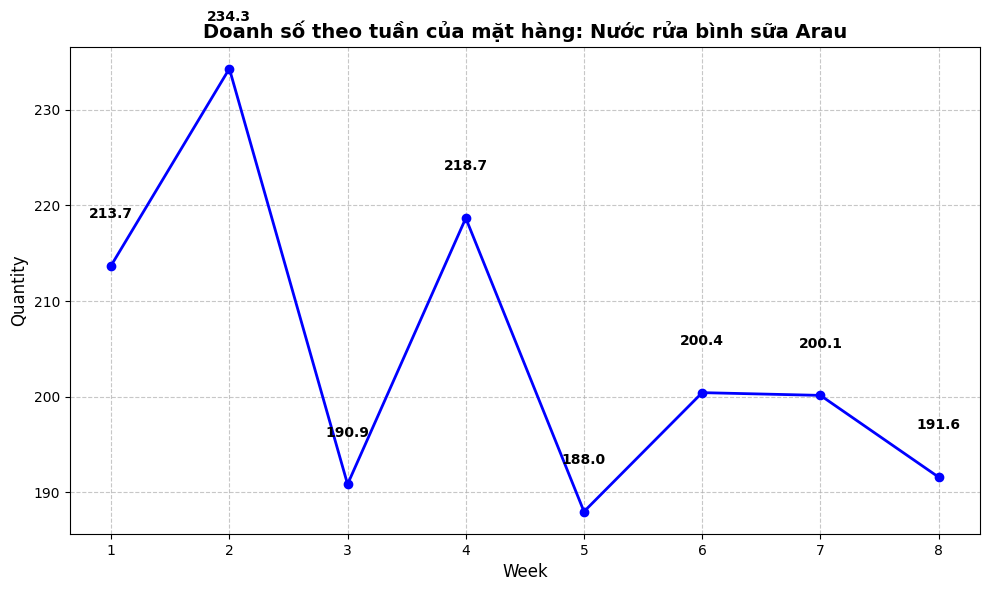

In [ ]:
def visualize(name, type):
    if type==0:
        df_filtered = df_cat.filter(pl.col("category") == name).sort("week_id")
    elif type==1:
        df_filtered = df_cat1.filter(pl.col("category_l1") == name).sort("week_id")
    elif type==2:
        df_filtered = df_cat2.filter(pl.col("category_l2") == name).sort("week_id")
    elif type==3:
        df_filtered = df_cat3.filter(pl.col("category_l3") == name).sort("week_id")
    elif type==4:
        df_filtered = df_item.filter(pl.col("item_id") == name).sort("week_id")

    plt.figure(figsize=(10, 6))

    plt.plot(df_filtered['week_id'], df_filtered['total_quantity'], marker='o', color='blue', linewidth=2)

    for x, y in zip(df_filtered['week_id'], df_filtered['total_quantity']):
        plt.text(x, y + (max(df_filtered['total_quantity']) * 0.02), f"{y:.1f}",
                ha='center', va='bottom', fontsize=10, color='black', fontweight='bold')

    plt.title(f"Doanh số theo tuần của mặt hàng: {name}", fontsize=14, fontweight='bold')
    plt.xlabel("Week", fontsize=12)
    plt.ylabel("Quantity", fontsize=12)

    plt.xticks([1,2,3,4,5,6,7,8])

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()

    plt.show()

visualize('Nước rửa bình sữa Arau', 0)

# 4. Statistic

In [ ]:
import polars as pl


def process_by_total(df, holiday_week_id):
    # B1. Total quantity theo tuần
    weekly_df = (
        df.group_by("week_id")
        .agg(pl.col("normalized_quantity").sum().alias("total_quantity"))
        .sort("week_id")
    )

    # B2. Mean quantity của các tuần không lễ
    non_holiday_mean = (
        weekly_df.filter(pl.col("week_id") != holiday_week_id)
        .select(pl.col("total_quantity").mean())
        .item()
    )

    # B3. Giá trị tuần lễ
    holiday_value = (
        weekly_df.filter(pl.col("week_id") == holiday_week_id)
        .select("total_quantity")
        .item()
    )

    # B4. uplift
    uplift = holiday_value - non_holiday_mean

    result_df = pl.DataFrame({
        "mean_non_holiday_week": [non_holiday_mean],
        "holiday_week_value": [holiday_value],
        "uplift_vs_normal": [uplift]
    })

    print(result_df)
    return result_df


def process_by_category_level(df, holiday_week_id, type_cate):
    result = []

    # tạo list tuần đầy đủ
    min_week = df.select(pl.col("week_id").min()).item()
    max_week = df.select(pl.col("week_id").max()).item()

    full_weeks = pl.DataFrame({
        "week_id": list(range(min_week, max_week + 1))
    })

    # danh sách category
    category_values = (
        df.select(pl.col(type_cate).drop_nulls().unique())
        .to_series()
        .to_list()
    )

    for cate in category_values:
        cate_df = df.filter(pl.col(type_cate) == cate)

        weekly_sum = (
            cate_df.group_by("week_id")
            .agg(pl.col("normalized_quantity").sum().alias("total_quantity"))
        )

        # fill tuần thiếu = 0
        weekly_df = (
            full_weeks.join(weekly_sum, on="week_id", how="left")
            .with_columns(pl.col("total_quantity").fill_null(0))
            .sort("week_id")
        )

        # mean tuần thường
        non_holiday_mean = (
            weekly_df.filter(pl.col("week_id") != holiday_week_id)
            .select(pl.col("total_quantity").mean())
            .item()
        )

        # value tuần lễ
        holiday_value = (
            weekly_df.filter(pl.col("week_id") == holiday_week_id)
            .select("total_quantity")
            .item()
        )

        uplift = holiday_value - non_holiday_mean

        result.append({
            type_cate: cate,
            "mean_non_holiday_week": non_holiday_mean,
            "holiday_week_value": holiday_value,
            "uplift_vs_normal": uplift
        })

    result = (
        pl.DataFrame(result)
        .sort("uplift_vs_normal", descending=True, nulls_last=True)
    )

    print(result)
    return result


def process_statistic(df, holiday_week_id):
    total_stat_df = process_by_total(df, holiday_week_id)
    cat1_stat_df = process_by_category_level(df, holiday_week_id, "category_l1")
    cat2_stat_df = process_by_category_level(df, holiday_week_id, "category_l2")
    cat3_stat_df = process_by_category_level(df, holiday_week_id, "category_l3")
    cat_stat_df = process_by_category_level(df, holiday_week_id, "category")
    item_id_stat_df = process_by_category_level(df, holiday_week_id, "item_id")

    return {
        "total": total_stat_df,
        "cat1": cat1_stat_df,
        "cat2": cat2_stat_df,
        "cat3": cat3_stat_df,
        "category": cat_stat_df
    }


In [ ]:
process_statistic(df_final, holiday_week_id=8)

shape: (1, 3)
┌───────────────────────┬────────────────────┬──────────────────┐
│ mean_non_holiday_week ┆ holiday_week_value ┆ uplift_vs_normal │
│ ---                   ┆ ---                ┆ ---              │
│ f64                   ┆ f64                ┆ f64              │
╞═══════════════════════╪════════════════════╪══════════════════╡
│ 154870.097506         ┆ 133586.4           ┆ -21283.697506    │
└───────────────────────┴────────────────────┴──────────────────┘
shape: (14, 4)
┌────────────────────────┬───────────────────────┬────────────────────┬──────────────────┐
│ category_l1            ┆ mean_non_holiday_week ┆ holiday_week_value ┆ uplift_vs_normal │
│ ---                    ┆ ---                   ┆ ---                ┆ ---              │
│ str                    ┆ f64                   ┆ f64                ┆ f64              │
╞════════════════════════╪═══════════════════════╪════════════════════╪══════════════════╡
│ Phụ kiện               ┆ 1659.44898            ┆ 167

{'total': shape: (1, 3)
 ┌───────────────────────┬────────────────────┬──────────────────┐
 │ mean_non_holiday_week ┆ holiday_week_value ┆ uplift_vs_normal │
 │ ---                   ┆ ---                ┆ ---              │
 │ f64                   ┆ f64                ┆ f64              │
 ╞═══════════════════════╪════════════════════╪══════════════════╡
 │ 154870.097506         ┆ 133586.4           ┆ -21283.697506    │
 └───────────────────────┴────────────────────┴──────────────────┘,
 'cat1': shape: (14, 4)
 ┌────────────────────────┬───────────────────────┬────────────────────┬──────────────────┐
 │ category_l1            ┆ mean_non_holiday_week ┆ holiday_week_value ┆ uplift_vs_normal │
 │ ---                    ┆ ---                   ┆ ---                ┆ ---              │
 │ str                    ┆ f64                   ┆ f64                ┆ f64              │
 ╞════════════════════════╪═══════════════════════╪════════════════════╪══════════════════╡
 │ Phụ kiện           

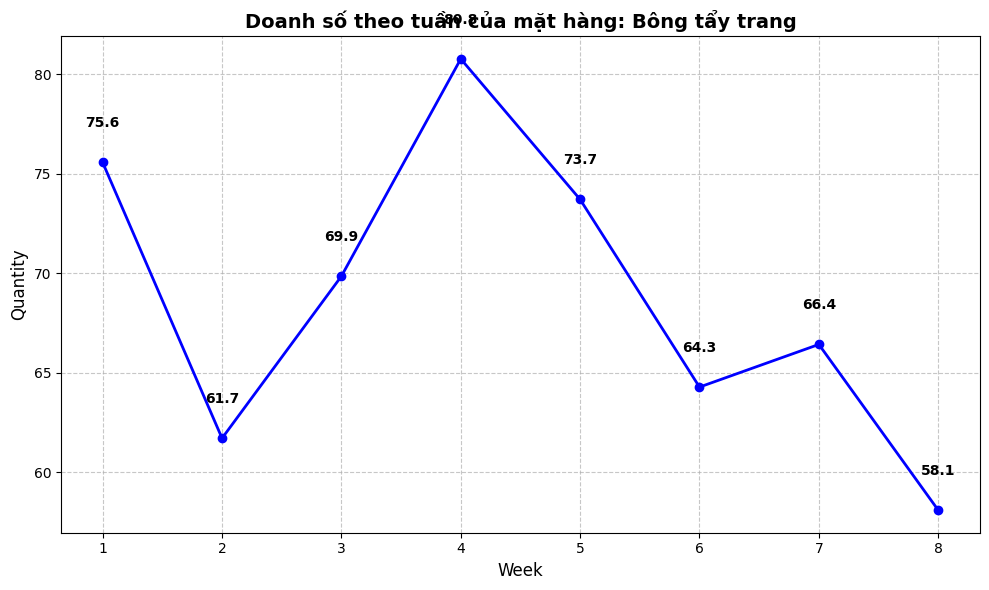

In [ ]:
visualize("Bánh & Kẹo cho bé", 2)

In [ ]:
print(df["category_l2"].unique().to_list())

['A2 milk company', 'Bình sữa, phụ kiện', 'Enfa', 'TPCN cho gia đình', 'Chăm sóc da', 'Mứt & Bơ phết', 'Chăm sóc răng miệng', 'Trà & Cà phê', 'Chăm sóc gia đình', 'Bột ăn dặm', 'Caryn', 'Dầu sức khỏe', 'Chăm sóc mẹ trước & sau sinh', 'Aptamil Úc', 'Chăm sóc cơ thể', 'Thực phẩm đông lạnh', 'Khẩu trang', 'Nón', 'Kẹo', 'Đồ dùng ra ngoài', 'Bột lắc sữa', 'Thời trang đông', 'Gối', 'Đồ dùng cho mẹ', 'Đồ uống', 'Thời trang bé trai', 'Cơ cấu hàng tồn', 'Nước rửa bình sữa', 'Sức khỏe gia đình', 'Giấy', 'Humana', 'Glico', 'Dầu ăn & Gia vị', 'Băng vệ sinh', 'TP từ sữa (bảo quản thường)', 'TPCN cho bé', 'Đồ dùng ăn uống', 'Bubs', 'Vệ sinh dụng cụ & bề mặt', 'Bánh & Kẹo cho bé', 'Abbott', 'Blackmores', 'Chăn', 'Confidence', 'Phụ kiện khác', 'Maeil', 'Nestle', 'Nutifood', 'Merries', 'Purelac', 'Cơ cấu hàng cũ', 'Đồ dùng vệ sinh', 'Snack ăn dặm', 'Giặt xả gia đình', 'Mì & Đồ khô ăn liền', 'Goon', 'Đồ dùng bé ngủ ngon', 'Kabrita', 'Meiji Nội địa', 'Quần áo & Phụ kiện sơ sinh', 'Rascal', 'Chăn ga gối g